<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/ANN_using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import torch
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
# check for gpu
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# set the random seed for productivity
torch.manual_seed(42)

In [4]:
df=pd.read_csv("/content/fashion-mnist_train.csv")

In [5]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


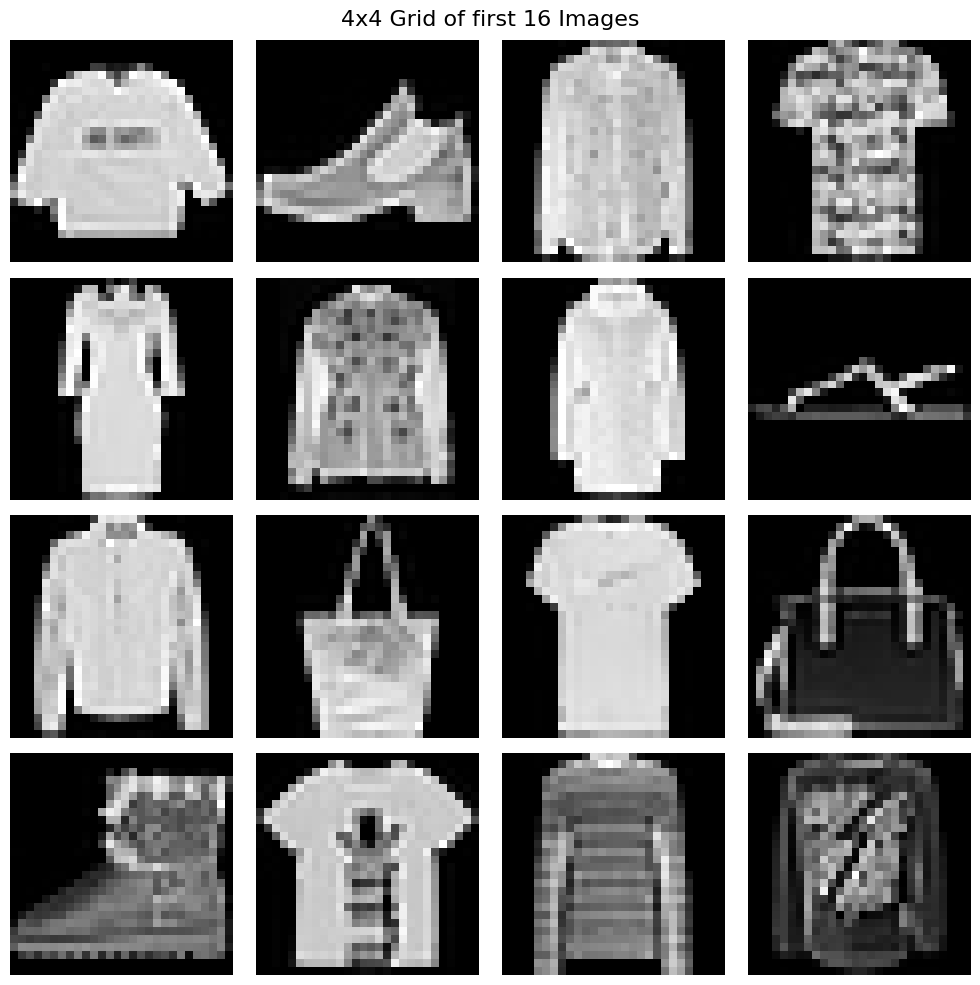

In [6]:
# create a 4*4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4x4 Grid of first 16 Images', fontsize=16)
# plot the forst 16 images of dataset
for i,ax in enumerate(axes.flatten()):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img,cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [9]:
# create customdataset class
class CustomDataset(Dataset):
    def __init__(self,features,labels):

        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]


In [10]:
# create train dataset object
train_dataset=CustomDataset(X_train,y_train)

In [11]:
# create test dataset object
test_dataset=CustomDataset(X_test,y_test)

In [12]:
# create test and train data loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [32]:
# define NN class
class MyNN(nn.Module):
  def __init__(self,input_dim,output_dim,num_of_hidden_layer,neurons_per_layer):
    super().__init__()
    layers=[]

    for i in range (num_of_hidden_layer):
      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(p=0.3))
      input_dim=neurons_per_layer
    layers.append(nn.Linear(neurons_per_layer,output_dim))
    self.model=nn.Sequential(*layers)
  def forward(self,X):
    return self.model(X)


In [33]:
# defining objective function
def objective_function(trial):
  # next hyperparamter value from the search space
  num_hidden_layers=trial.suggest_int("num_hidden_layers",1,5)
  neurons_per_layer=trial.suggest_int("neurons_per_layer",8,128,step=8)
  # model init
  input_dim=X_train.shape[1]
  output_dim=10
  model=MyNN(input_dim,output_dim,num_hidden_layers,neurons_per_layer)
  model.to(device)


  # params init
  learning_rate=0.1
  epochs=100

  # optimizer selection
  # loss function
  criterion=nn.CrossEntropyLoss()

  # optimizer
  optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)


  # training loop
  for epoch in range(epochs):
    for batch_features,batch_labels in train_loader:
      # move data to gpu
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
      # forward
      outputs=model(batch_features)
      # calculate losss
      loss=criterion(outputs,batch_labels)
      # back pass
      optimizer.zero_grad()
      loss.backward()
      # update
      optimizer.step()
  # evaluation
  model.eval()
  with torch.no_grad():
    total=0
    correct=0
    for batch_features,batch_labels in train_loader:
      # move data to gpu
      batch_features=batch_features.to(device)
      batch_labels=batch_labels.to(device)
      # forward
      outputs=model(batch_features)
      _,predicted=torch.max(outputs,1)
      # calculate loss
      total=total+batch_labels.size(0)
      correct=correct+(predicted==batch_labels).sum().item()
  accuracy=100*correct/total
  return accuracy

In [34]:
!pip install optuna

In [35]:
import optuna
study=optuna.create_study(direction="maximize")


[I 2026-08-18 08:25:36,880] A new study created in memory with name: no-name-0bf89227-0ada-4da3-919a-6bd943465452


In [1]:
# study.optimize(objective_function,n_trials=10)

In [15]:
# # define NN class
# class NN(nn.Module):
#   def __init__(self,num_features):
#     super().__init__()
#     self.model=nn.Sequential(
#         nn.Linear(num_features,128),
#         nn.BatchNorm1d(128),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),
#         nn.Linear(128,64),
#         nn.BatchNorm1d(64),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),
#         nn.Linear(64,10)
#     )
#   def forward(self,X):
#     return self.model(X)


In [16]:
# # set learning rate and epoches
# learning_rate=0.1
# epochs=100

In [17]:
# instatiate the model
# model=NN(num_features=X_train.shape[1])
# model.to(device)

# loss function
# criterion=nn.CrossEntropyLoss()

# # optimizer
# optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)


In [23]:
# training loop
# for epoch in range(epochs):
#   total_epoches_loss=0
#   for batch_features,batch_labels in train_loader:

#     # move data to gpu
#     batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
#     # forward
#     outputs=model(batch_features)
#     # calculate losss
#     loss=criterion(outputs,batch_labels)
#     # back pass
#     optimizer.zero_grad()
#     loss.backward()
#     # update
#     optimizer.step()

#     total_epoches_loss+=loss.item()
#   print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoches_loss/len(train_loader)}")


In [24]:
# set model to evaluation
# model.eval()


In [21]:
# with torch.no_grad():
#   total=0
#   correct=0
#   for batch_features,batch_labels in train_loader:
#     # move data to gpu
#     batch_features=batch_features.to(device)
#     batch_labels=batch_labels.to(device)
#     # forward
#     outputs=model(batch_features)
#     _,predicted=torch.max(outputs,1)
#     # calculate loss
#     total=total+batch_labels.size(0)
#     correct=correct+(predicted==batch_labels).sum().item()
#   print(f"Accuracy: {100*correct/total}")

Accuracy: 93.25416666666666
